In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set general style for the charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

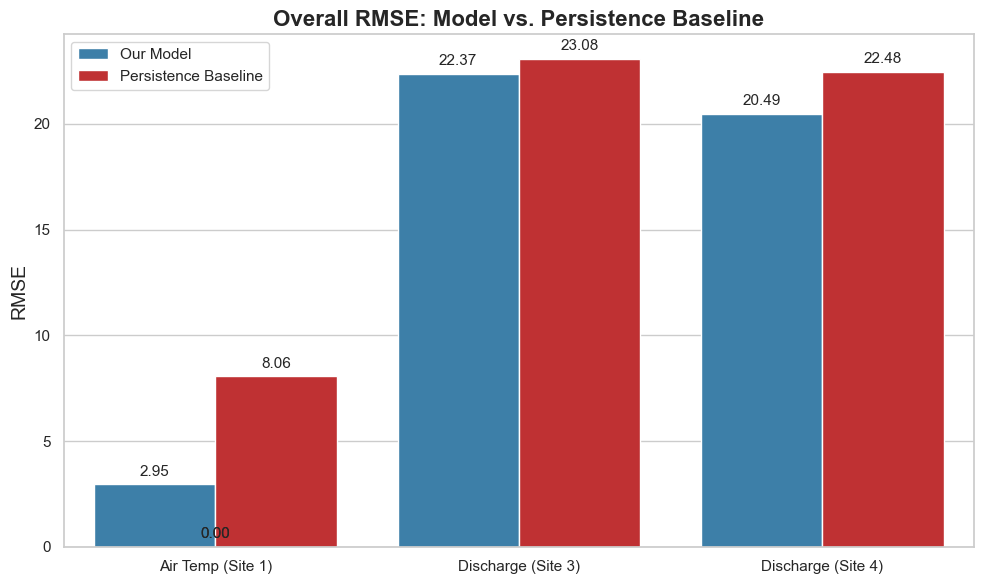

In [5]:
# 1. Load the overall metrics files
df_air = pd.read_csv('air_temperature_overall_validation_metrics.csv')
df_discharge = pd.read_csv('discharge_overall_validation_metrics.csv')

records = []

# Extract Air Temp Site 1
s1 = df_air[df_air['site_id'] == 1].iloc[0]
records.append({'Metric': 'Air Temp (Site 1)', 'Model Type': 'Our Model', 'RMSE': s1['rmse']})
records.append({'Metric': 'Air Temp (Site 1)', 'Model Type': 'Persistence Baseline', 'RMSE': s1['persistence_rmse']})

# Extract Discharge Site 3
s3 = df_discharge[df_discharge['site_id'] == 3].iloc[0]
records.append({'Metric': 'Discharge (Site 3)', 'Model Type': 'Our Model', 'RMSE': s3['rmse']})
records.append({'Metric': 'Discharge (Site 3)', 'Model Type': 'Persistence Baseline', 'RMSE': s3['persistence_rmse']})

# Extract Discharge Site 4
s4 = df_discharge[df_discharge['site_id'] == 4].iloc[0]
records.append({'Metric': 'Discharge (Site 4)', 'Model Type': 'Our Model', 'RMSE': s4['rmse']})
records.append({'Metric': 'Discharge (Site 4)', 'Model Type': 'Persistence Baseline', 'RMSE': s4['persistence_rmse']})

df_overall = pd.DataFrame(records)

# Plot the chart
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=df_overall, x='Metric', y='RMSE', hue='Model Type', palette=['#2b83ba', '#d7191c'])
plt.title('Overall RMSE: Model vs. Persistence Baseline', fontsize=16, fontweight='bold')
plt.ylabel('RMSE', fontsize=14)
plt.xlabel('')
plt.legend(title='')

# Add value labels
for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.2f'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', 
                 xytext = (0, 9), 
                 textcoords = 'offset points',
                 fontsize=11)
                 
plt.tight_layout()
plt.show()

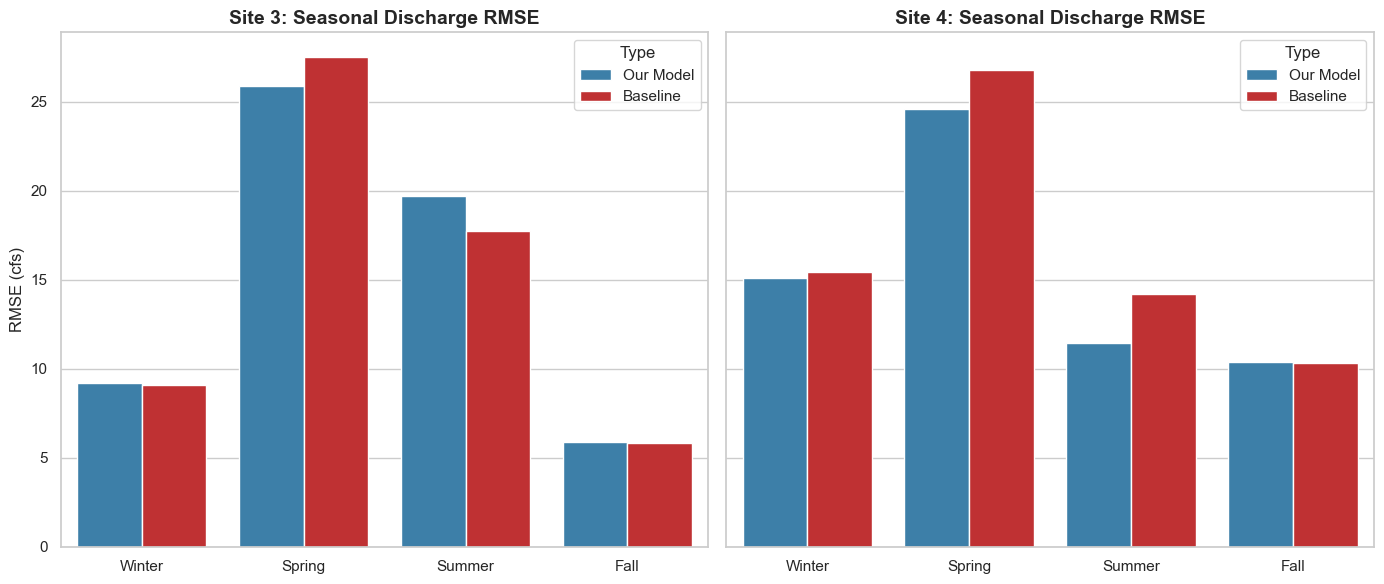

In [6]:
# 1. Load the seasonal metrics file
df_season = pd.read_csv('discharge_metrics_by_season.csv')

# 2. Restructure data dynamically for the seaborn plot
records = []
for _, row in df_season.iterrows():
    site_label = f"Site {int(row['site_id'])}"
    season = str(row['season']).capitalize()
    
    # Add Our Model row
    records.append({
        'Site': site_label,
        'Season': season,
        'Type': 'Our Model',
        'RMSE': row['rmse']
    })
    # Add Baseline row
    records.append({
        'Site': site_label,
        'Season': season,
        'Type': 'Baseline',
        'RMSE': row['persistence_rmse']
    })

df_seasonal = pd.DataFrame(records)

# Order seasons logically
df_seasonal['Season'] = pd.Categorical(df_seasonal['Season'], categories=['Winter', 'Spring', 'Summer', 'Fall'], ordered=True)

# 3. Plot the side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(data=df_seasonal[df_seasonal['Site'] == 'Site 3'], x='Season', y='RMSE', hue='Type', ax=axes[0], palette=['#2b83ba', '#d7191c'])
axes[0].set_title('Site 3: Seasonal Discharge RMSE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE (cfs)', fontsize=12)
axes[0].set_xlabel('')

sns.barplot(data=df_seasonal[df_seasonal['Site'] == 'Site 4'], x='Season', y='RMSE', hue='Type', ax=axes[1], palette=['#2b83ba', '#d7191c'])
axes[1].set_title('Site 4: Seasonal Discharge RMSE', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

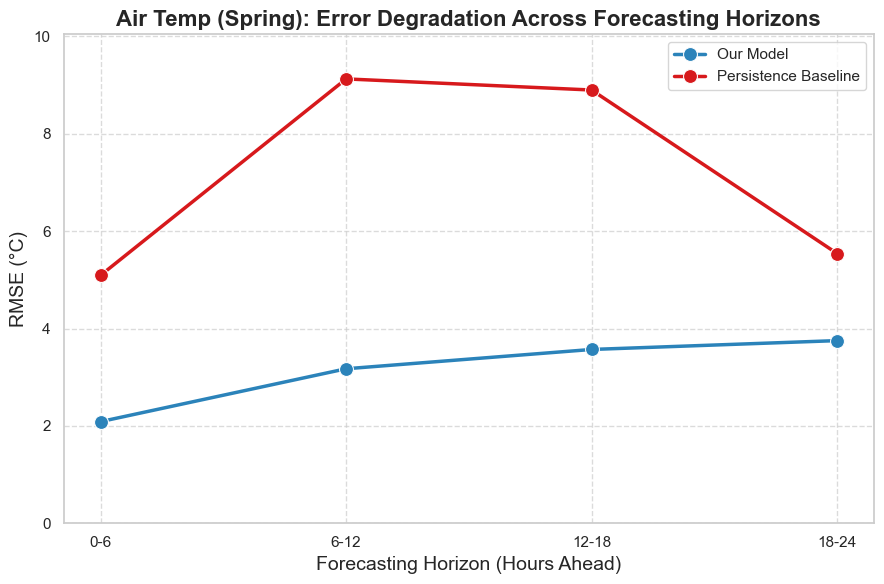

In [7]:
# 1. Load the horizon metrics file
df_horizon = pd.read_csv('air_temperature_metrics_by_season_horizon.csv')

# 2. Filter dynamically for Site 1, Spring season
df_spring = df_horizon[(df_horizon['site_id'] == 1) & (df_horizon['season'] == 'spring')].copy()

# 3. Restructure for the lineplot
records = []
for _, row in df_spring.iterrows():
    records.append({'Horizon': row['horizon_bin'], 'Model Type': 'Our Model', 'RMSE': row['rmse']})
    records.append({'Horizon': row['horizon_bin'], 'Model Type': 'Persistence Baseline', 'RMSE': row['persistence_rmse']})

df_plot = pd.DataFrame(records)

# 4. Plot the line chart
plt.figure(figsize=(9, 6))
sns.lineplot(data=df_plot, x='Horizon', y='RMSE', hue='Model Type', marker='o', linewidth=2.5, markersize=10, palette=['#2b83ba', '#d7191c'])
plt.title('Air Temp (Spring): Error Degradation Across Forecasting Horizons', fontsize=16, fontweight='bold')
plt.ylabel('RMSE (°C)', fontsize=14)
plt.xlabel('Forecasting Horizon (Hours Ahead)', fontsize=14)

# Set the Y-axis limit dynamically based on the max value in the data
max_val = df_plot['RMSE'].max()
plt.ylim(0, max_val * 1.1) 

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='')

plt.tight_layout()
plt.show()

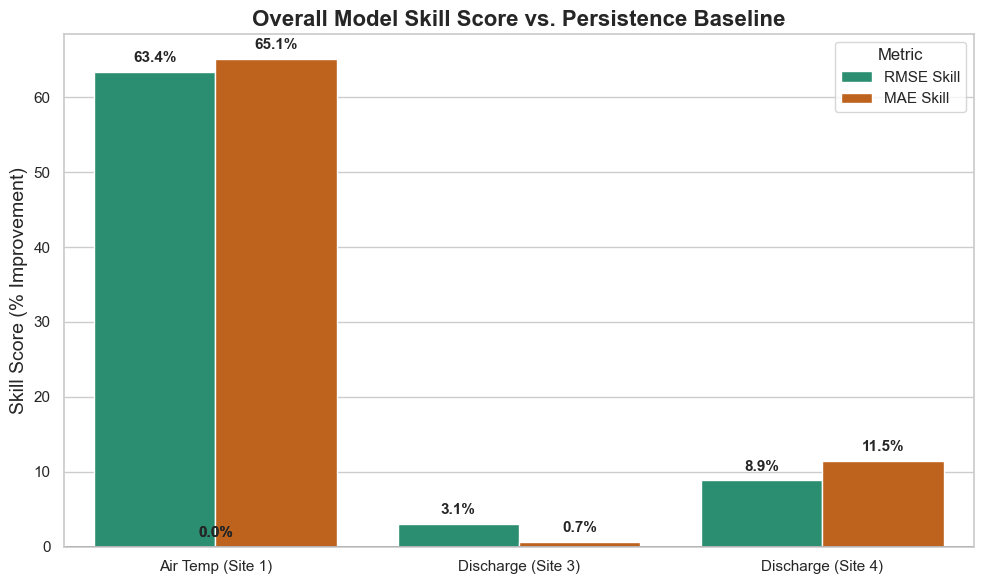

In [2]:
# 1. Load the overall metrics files
df_air_overall = pd.read_csv('air_temperature_overall_validation_metrics.csv')
df_discharge_overall = pd.read_csv('discharge_overall_validation_metrics.csv')

# 2. Extract and format the data dynamically
records = []

# Air Temp (Site 1)
site1 = df_air_overall[df_air_overall['site_id'] == 1].iloc[0]
records.append({'Variable (Site)': 'Air Temp (Site 1)', 'Metric': 'RMSE Skill', 'Skill Score (%)': site1['rmse_skill_vs_persistence'] * 100})
records.append({'Variable (Site)': 'Air Temp (Site 1)', 'Metric': 'MAE Skill', 'Skill Score (%)': site1['mae_skill_vs_persistence'] * 100})

# Discharge (Site 3)
site3 = df_discharge_overall[df_discharge_overall['site_id'] == 3].iloc[0]
records.append({'Variable (Site)': 'Discharge (Site 3)', 'Metric': 'RMSE Skill', 'Skill Score (%)': site3['rmse_skill_vs_persistence'] * 100})
records.append({'Variable (Site)': 'Discharge (Site 3)', 'Metric': 'MAE Skill', 'Skill Score (%)': site3['mae_skill_vs_persistence'] * 100})

# Discharge (Site 4)
site4 = df_discharge_overall[df_discharge_overall['site_id'] == 4].iloc[0]
records.append({'Variable (Site)': 'Discharge (Site 4)', 'Metric': 'RMSE Skill', 'Skill Score (%)': site4['rmse_skill_vs_persistence'] * 100})
records.append({'Variable (Site)': 'Discharge (Site 4)', 'Metric': 'MAE Skill', 'Skill Score (%)': site4['mae_skill_vs_persistence'] * 100})

df_skill = pd.DataFrame(records)

# 3. Plot the chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_skill, x='Variable (Site)', y='Skill Score (%)', hue='Metric', palette=['#1b9e77', '#d95f02'])
plt.title('Overall Model Skill Score vs. Persistence Baseline', fontsize=16, fontweight='bold')
plt.ylabel('Skill Score (% Improvement)', fontsize=14)
plt.xlabel('')
plt.axhline(0, color='black', linewidth=1.2)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'bottom', 
                 xytext = (0, 5), 
                 textcoords = 'offset points',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\krish\AppData\Local\Temp\ipykernel_9196\2426376641.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df_s3, x='Season', y='RMSE Skill Score (%)', palette=colors)


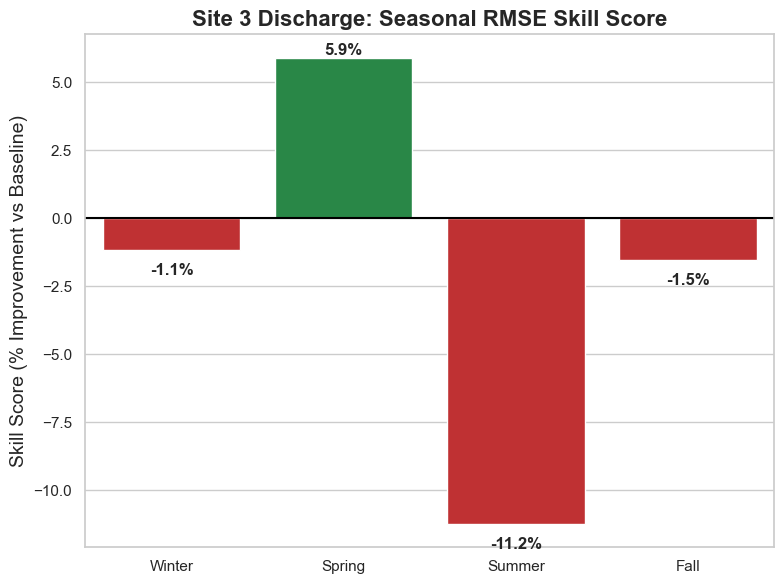

In [3]:
# 1. Load the seasonal metrics file
df_discharge_season = pd.read_csv('discharge_metrics_by_season.csv')

# 2. Filter for Site 3 and calculate percentage
df_s3 = df_discharge_season[df_discharge_season['site_id'] == 3].copy()
df_s3['RMSE Skill Score (%)'] = df_s3['rmse_skill_vs_persistence'] * 100
df_s3['Season'] = df_s3['season'].str.capitalize()

# Order seasons logically
df_s3['Season'] = pd.Categorical(df_s3['Season'], categories=['Winter', 'Spring', 'Summer', 'Fall'], ordered=True)
df_s3 = df_s3.sort_values('Season')

# Create diverging color array (green for positive, red for negative)
colors = ['#d7191c' if val < 0 else '#1a9641' for val in df_s3['RMSE Skill Score (%)']]

# 3. Plot the chart
plt.figure(figsize=(8, 6))
ax2 = sns.barplot(data=df_s3, x='Season', y='RMSE Skill Score (%)', palette=colors)
plt.title('Site 3 Discharge: Seasonal RMSE Skill Score', fontsize=16, fontweight='bold')
plt.ylabel('Skill Score (% Improvement vs Baseline)', fontsize=14)
plt.xlabel('')
plt.axhline(0, color='black', linewidth=1.5)

# Add value labels
for p in ax2.patches:
    val = p.get_height()
    y_offset = 5 if val > 0 else -15
    ax2.annotate(f"{val:.1f}%", 
                 (p.get_x() + p.get_width() / 2., val), 
                 ha = 'center', va = 'center', 
                 xytext = (0, y_offset), 
                 textcoords = 'offset points',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

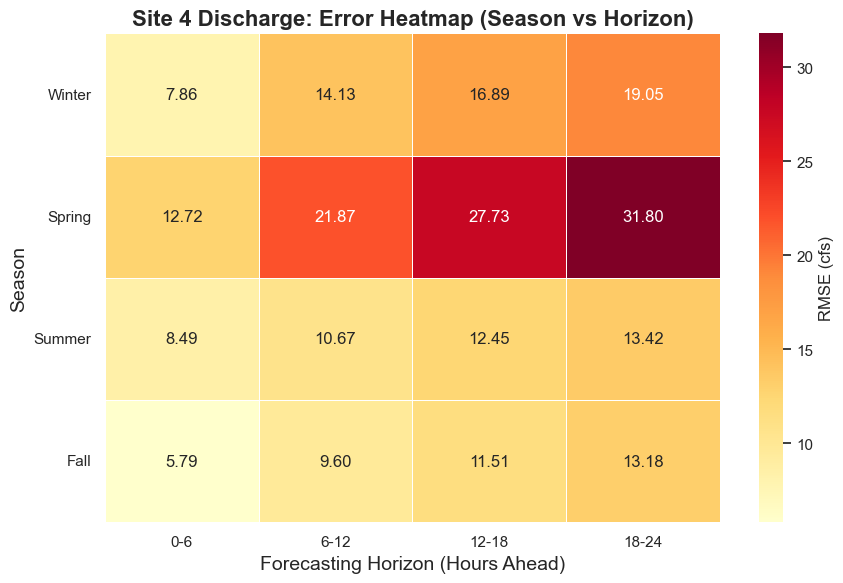

In [4]:
# 1. Load the horizon metrics file
df_discharge_horizon = pd.read_csv('discharge_metrics_by_season_horizon.csv')

# 2. Filter for Site 4 and format data
df_s4_horizon = df_discharge_horizon[df_discharge_horizon['site_id'] == 4].copy()
df_s4_horizon['Season'] = df_s4_horizon['season'].str.capitalize()

# 3. Pivot the dataframe to create a matrix (Rows: Season, Columns: Horizon, Values: RMSE)
df_heat = df_s4_horizon.pivot(index='Season', columns='horizon_bin', values='rmse')

# Order the rows and columns logically
df_heat = df_heat.reindex(index=['Winter', 'Spring', 'Summer', 'Fall'])
df_heat = df_heat[['0-6', '6-12', '12-18', '18-24']]

# 4. Plot the heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df_heat, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=.5, cbar_kws={'label': 'RMSE (cfs)'})
plt.title('Site 4 Discharge: Error Heatmap (Season vs Horizon)', fontsize=16, fontweight='bold')
plt.ylabel('Season', fontsize=14)
plt.xlabel('Forecasting Horizon (Hours Ahead)', fontsize=14)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()